# Rust 속도·효율 종합 리포트 (3DGCL / QDF / DGCL)

**목적:** `연구노트.md`에 정리된 Rust 포팅 배경과 수치를 바탕으로, 로컬에서 재현 가능한 마이크로벤치(QDF 전처리, DGCL contrastive views)를 실행하고 표·그래프와 함께 한 번에 정리합니다.

**범위:** `qdf_io`(QDF 전처리·shard·LCAO 패치), `dig_io`(DGCL view·shard·split). 학습 전체 파이프라인은 비용이 크므로 본 노트에서는 **벤치 스크립트** 위주로 측정합니다.

**실행 팁:** Jupyter의 현재 작업 폴더가 레포 루트(`3DGCL`, `연구노트.md`가 보이는 위치)인지 확인하세요. 그렇지 않으면 설정 셀에서 `REPO = Path(r"C:\...\3DGCL")`처럼 절대 경로를 직접 지정할 수 있습니다.

**병렬·튜닝 확장:** `RAYON_NUM_THREADS`, `--rust-batch-size` 스윕과 학습 `num_workers` 안내는 같은 폴더의 **`rust_parallel_tuning_report.ipynb`** 를 참고하세요.

## 연구노트와의 대응

| 연구노트 섹션 | 본 노트북에서 하는 일 |
|---------------|----------------------|
| QDF Rust 포팅 방향, preprocess 프로파일 | §2에서 `profile_preprocess.py`로 NumPy vs Rust wall time 재측정 |
| `dig_io` view 벤치 | §3에서 `profile_views.py`로 Python vs Rust ms/call |
| LCAO `pad-impl` rust (현 환경 비추천) | §4 표로 **문헌(노트) 수치**만 정리 — 전체 train 벤치는 생략 |
| Pretrain 병목(PyG Batch) | §4 결론 — Rust ROI 낮음, torch 벡터화 우선 |
| `qdf_io` 빌드 / stale `.pyd` | §1 환경 점검에서 `import qdf_io` 및 안내 |

레포 루트의 `연구노트.md`를 함께 열어두면 수치·맥락을 바로 대조할 수 있습니다.

In [1]:
from __future__ import annotations

import re
import subprocess
import sys
from pathlib import Path

REPO = Path.cwd().resolve()
for p in [REPO, *REPO.parents]:
    if (p / "연구노트.md").is_file():
        REPO = p
        break

# True: 빠른 스모크(분자 수·그래프 수 축소). False: 연구노트에 가까운 규모(시간 증가).
SMOKE = False
PRE_LIMIT = 120 if SMOKE else 1000
VIEWS_GRAPHS = 64 if SMOKE else 256
VIEWS_REPEAT = 3 if SMOKE else 5

PYTHON = sys.executable
PROFILE_PRE = REPO / "QuantumDeepField_molecule" / "bench" / "profile_preprocess.py"
PROFILE_VIEWS = REPO / "examples" / "sslgraph" / "bench" / "profile_views.py"
NOTE = REPO / "연구노트.md"

pre_results: dict = {}
views_rows: list = []

print("REPO =", REPO)
print("SMOKE =", SMOKE, "| PRE_LIMIT =", PRE_LIMIT)

REPO = C:\DGCL\3DGCL
SMOKE = False | PRE_LIMIT = 1000


## 1. 환경 점검

- Python / OS
- `qdf_io`, `dig_io` 네이티브 모듈 사용 가능 여부 (연구노트의 stale `.pyd` 이슈 참고)

In [2]:
import platform

print("python:", sys.version.split()[0], "| platform:", platform.platform())
print("연구노트 exists:", NOTE.is_file(), NOTE)
print("profile_preprocess:", PROFILE_PRE.is_file(), PROFILE_PRE)
print("profile_views:", PROFILE_VIEWS.is_file(), PROFILE_VIEWS)

if not PROFILE_PRE.is_file() or not PROFILE_VIEWS.is_file():
    raise FileNotFoundError(
        "벤치 스크립트를 찾을 수 없습니다. Jupyter 실행 cwd를 레포 루트로 두거나 위 REPO 경로를 수정하세요."
    )

# qdf_io
try:
    import qdf_io

    _qw = getattr(qdf_io, "ShardWriter", None)
    print("qdf_io: OK", "| ShardWriter:", _qw is not None)
except Exception as e:
    print("qdf_io: FAILED —", repr(e))
    print("  → QuantumDeepField_molecule/qdf_io 에서 maturin develop --release 또는 cargo build --release")

# dig_io
try:
    import dig_io

    avail = getattr(dig_io, "is_available", lambda: True)()
    print("dig_io: import OK | is_available:", avail)
except Exception as e:
    print("dig_io: FAILED —", repr(e))

python: 3.10.20 | platform: Windows-10-10.0.26200-SP0
연구노트 exists: True C:\DGCL\3DGCL\연구노트.md
profile_preprocess: True C:\DGCL\3DGCL\QuantumDeepField_molecule\bench\profile_preprocess.py
profile_views: True C:\DGCL\3DGCL\examples\sslgraph\bench\profile_views.py
qdf_io: OK | ShardWriter: True
dig_io: import OK | is_available: True


## 2. QDF 전처리 벤치 (`profile_preprocess.py`)

`train/preprocess.py`와 동일한 루프를 `--no-save`로 돌려 **디스크 IO를 제외**한 계산 비용을 비교합니다. Rust 경로는 `qdf_io.preprocess_batch_rust`(Rayon, GIL 해제).

- 데이터셋 기본: `QM9under14atoms_atomizationenergy_eV` / `train` (연구노트와 동일 계열)

In [3]:
def run_cmd(args: list[str], cwd: Path | None = None) -> subprocess.CompletedProcess:
    return subprocess.run(
        [PYTHON, *args],
        cwd=str(cwd or REPO),
        capture_output=True,
        text=True,
        encoding="utf-8",
        errors="replace",
    )


def parse_preprocess_wall(text: str) -> float | None:
    m = re.search(r"wall time\s+:\s+([\d.]+)\s+s", text)
    return float(m.group(1)) if m else None


def parse_preprocess_ms_per_mol(text: str) -> float | None:
    m = re.search(r"wall time\s+:\s+[\d.]+\s+s\s+\(([\d.]+)\s+ms/molecule\)", text)
    return float(m.group(1)) if m else None


pre_results: dict[str, dict] = {}
if PROFILE_PRE.is_file():
    for backend in ("numpy", "rust"):
        extra = []
        if backend == "rust":
            extra = ["--backend", "rust", "--rust-batch-size", "64"]
        cp = run_cmd(
            [
                str(PROFILE_PRE),
                "--dataset",
                "QM9under14atoms_atomizationenergy_eV",
                "--split",
                "train",
                "--limit",
                str(PRE_LIMIT),
                "--no-save",
                *extra,
            ]
        )
        out = (cp.stdout or "") + ("\n--- STDERR ---\n" + cp.stderr if cp.stderr else "")
        wall = parse_preprocess_wall(cp.stdout or "")
        mpm = parse_preprocess_ms_per_mol(cp.stdout or "")
        pre_results[backend] = {
            "returncode": cp.returncode,
            "wall_s": wall,
            "ms_per_mol": mpm,
            "stdout_tail": "\n".join((cp.stdout or "").strip().splitlines()[-12:]),
        }
        print(f"=== backend={backend} rc={cp.returncode} wall_s={wall} ===")
        print(pre_results[backend]["stdout_tail"])
else:
    print("SKIP: profile_preprocess.py missing")

=== backend=numpy rc=0 wall_s=4.064 ===
distmat_orbitals      :    3.319 s  ( 81.7%)    3.319 ms/molecule
distmat_atoms         :    0.231 s  (  5.7%)    0.231 ms/molecule
create_field          :    0.206 s  (  5.1%)    0.206 ms/molecule
parse_molecule        :    0.115 s  (  2.8%)    0.115 ms/molecule
potential             :    0.099 s  (  2.4%)    0.099 ms/molecule
assemble              :    0.088 s  (  2.2%)    0.088 ms/molecule
------------------------------------------------------------
sum of steps          :    4.058 s
wall time             :    4.064 s  (4.064 ms/molecule)
molecules             : 1000

Extrapolation to QM9full (~130k molecules) at this rate: 8.8 minutes (single thread)
=== backend=rust rc=0 wall_s=0.208 ===
backend               : rust
rust_batch_size       : 64
rust_preprocess_batch :    0.113 s  ( 54.7%)    0.113 ms/molecule
parse_molecule        :    0.066 s  ( 31.7%)    0.066 ms/molecule
assemble              :    0.003 s  (  1.2%)    0.003 ms/molecule
rust

## 3. DGCL contrastive views (`profile_views.py`)

합성 `torch_geometric.data.Batch`에 대해 `UniformSample`, `RWSample`, `EdgePerturbation`을 Python vs `impl='rust'`로 반복 호출합니다. RDKit·데이터셋 불필요.

- `dig_io` 미빌드 시 Rust 줄은 스킵되거나 예외로 표시될 수 있습니다.

In [4]:
def parse_views_means(text: str) -> list[tuple[str, str, float]]:
    rows: list[tuple[str, str, float]] = []
    cur = ""
    for line in text.splitlines():
        s = line.strip()
        if s.startswith("[") and s.endswith("]"):
            cur = s[1:-1]
            continue
        m = re.match(r"(python|rust)\s*:\s+([\d.]+)\s+ms", s)
        if m and cur:
            rows.append((cur, m.group(1), float(m.group(2))))
    return rows


views_rows: list[tuple[str, str, float]] = []
views_text = ""
if PROFILE_VIEWS.is_file():
    cp = run_cmd(
        [
            str(PROFILE_VIEWS),
            "--n-graphs",
            str(VIEWS_GRAPHS),
            "--n-nodes",
            "40",
            "--n-edges",
            "200",
            "--repeat",
            str(VIEWS_REPEAT),
            "--warmup",
            "1",
        ]
    )
    views_text = (cp.stdout or "") + (cp.stderr or "")
    views_rows = parse_views_means(cp.stdout or "")
    print("rc=", cp.returncode)
    print(cp.stdout)
    if cp.returncode != 0 and cp.stderr:
        print("stderr:\n", cp.stderr)
else:
    print("SKIP: profile_views.py missing")

rc= 0
batch: n_graphs=256, n_nodes=40, n_edges=200, repeat=5 (+1 warmup)

[UniformSample(gin)]
  python:    49.32 ms  (min 43.27, max 58.48)
  rust  :    30.51 ms  (min 21.81, max 38.48)

[RWSample(ratio=0.5)]
  python:   182.75 ms  (min 147.18, max 267.60)
  rust  :    23.48 ms  (min 20.26, max 26.75)

[EdgePerturbation(add+drop)]
  python:   196.80 ms  (min 166.52, max 237.89)
  rust  :    31.41 ms  (min 29.91, max 32.61)



## 4. 연구노트에 정리된 정량 요약 (참고값)

아래는 **이전에 노트에 기록된 대표 수치**입니다. 기계·캐시·빌드가 다르면 절대값은 달라질 수 있으나, 방향성(전처리 Rust 유리, LCAO rust 패치는 당시 환경에서 비효율 등)을 잡는 용도입니다.

### QDF `profile_preprocess` (train 1000분자, `--no-save`, 8코어 예시)

| backend | wall (대략) | 상대 |
|---------|-------------|------|
| numpy | ~8.74 s | 1× |
| rust batch 64 | ~0.39 s | ~22× |

### LCAO pad (`QM9under14atoms`, shard, warm cache, 60×2 batches 예시)

| `--pad-impl` | 전체 wall (대략) | 비고 |
|----------------|------------------|------|
| python | ~36 s | 기준 |
| rust-pad-only | ~48 s | pad만 Rust여도 총합 악화 |
| rust (pad+list_to_batch) | ~72 s | bwd 등 증가 |

### DGCL views (`profile_views` 스타일, 노트의 합성 배치 예시)

Uniform / Edge 등 커널별로 Rust가 **수 배~수십 배** 빠른 경우가 있으나, RWSample은 `edge_index` numpy 변환 비용으로 격차가 좁을 수 있음.

### Pretrain (SSLGraph)

병목이 PyG `to_data_list` / `from_data_list`에 있어 **Rust view만으로는 ROI 거의 없음** → torch 쪽 벡터화가 우선이라는 결론(연구노트 § Pretrain 속도).

,backend,wall_s,ms_per_mol,ok,numpy_wall_over_rust_wall
0,numpy,4.064,4.064,True,<NA>
1,rust,0.208,0.208,True,19.538462


impl,python,rust,ratio_py_rust
kernel,,,
EdgePerturbation(add+drop),196.80,31.41,6.265521
RWSample(ratio=0.5),182.75,23.48,7.783220
UniformSample(gin),49.32,30.51,1.616519


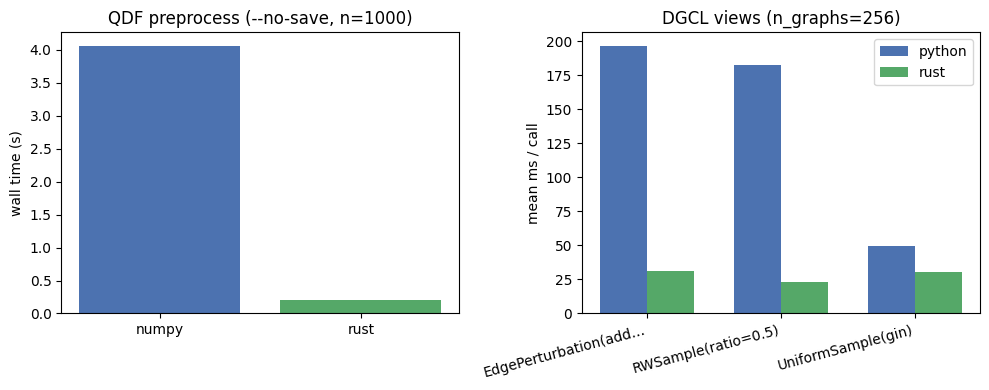

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# --- QDF: 이번 실행 요약 ---
rows_pre = []
for b in ("numpy", "rust"):
    r = pre_results.get(b) or {}
    rows_pre.append(
        {
            "backend": b,
            "wall_s": r.get("wall_s"),
            "ms_per_mol": r.get("ms_per_mol"),
            "ok": r.get("returncode") == 0 and r.get("wall_s") is not None,
        }
    )
df_pre = pd.DataFrame(rows_pre)
if len(df_pre) == 2:
    n_wall = df_pre.loc[df_pre["backend"] == "numpy", "wall_s"].iloc[0]
    r_wall = df_pre.loc[df_pre["backend"] == "rust", "wall_s"].iloc[0]
    if pd.notna(n_wall) and pd.notna(r_wall) and float(r_wall) > 0:
        df_pre["numpy_wall_over_rust_wall"] = pd.NA
        df_pre.loc[df_pre["backend"] == "rust", "numpy_wall_over_rust_wall"] = float(n_wall) / float(
            r_wall
        )

try:
    display(df_pre)
except NameError:
    print(df_pre.to_string(index=False))

# --- DGCL: 이번 실행 피벗 ---
if views_rows:
    df_v = pd.DataFrame(views_rows, columns=["kernel", "impl", "mean_ms"])
    pivot = df_v.pivot_table(index="kernel", columns="impl", values="mean_ms", aggfunc="first")
    if "python" in pivot.columns and "rust" in pivot.columns:
        pivot["ratio_py_rust"] = pivot["python"] / pivot["rust"].replace(0, float("nan"))
    try:
        display(pivot)
    except NameError:
        print(pivot.to_string())
else:
    print("(views_rows 비어 있음 — dig_io 미설치 또는 스크립트 실패)")

# --- 막대 그래프 ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
if not df_pre.empty and df_pre["wall_s"].notna().any():
    sub = df_pre.dropna(subset=["wall_s"])
    ax.bar(sub["backend"].tolist(), sub["wall_s"].astype(float).tolist(), color=["#4C72B0", "#55A868"])
    ax.set_ylabel("wall time (s)")
    ax.set_title(f"QDF preprocess (--no-save, n={PRE_LIMIT})")
else:
    ax.text(0.5, 0.5, "no preprocess data", ha="center", va="center", transform=ax.transAxes)

ax2 = axes[1]
if views_rows:
    df_v = pd.DataFrame(views_rows, columns=["kernel", "impl", "mean_ms"])
    kernels = sorted(df_v["kernel"].unique())
    x = range(len(kernels))
    w = 0.35

    def mean_ms(k: str, impl: str) -> float:
        s = df_v[(df_v["kernel"] == k) & (df_v["impl"] == impl)]["mean_ms"]
        return float(s.iloc[0]) if len(s) else float("nan")

    py = [mean_ms(k, "python") for k in kernels]
    rs = [mean_ms(k, "rust") for k in kernels]
    ax2.bar([i - w / 2 for i in x], py, width=w, label="python", color="#4C72B0")
    ax2.bar([i + w / 2 for i in x], rs, width=w, label="rust", color="#55A868")
    ax2.set_xticks(list(x))
    ax2.set_xticklabels([k[:20] + "…" if len(k) > 20 else k for k in kernels], rotation=15, ha="right")
    ax2.set_ylabel("mean ms / call")
    ax2.set_title(f"DGCL views (n_graphs={VIEWS_GRAPHS})")
    ax2.legend()
else:
    ax2.text(0.5, 0.5, "no views data", ha="center", va="center", transform=ax2.transAxes)

plt.tight_layout()
plt.show()

## 5. 종합 결론 (연구노트 + 본 실행)

1. **QDF 전처리 (`--backend rust`)**  
   기하·거리·포텐셜 등 CPU 병목을 Rayon으로 넘기면 **wall time이 크게 줄어드는 경우가 많음**. 다만 `parse_molecule` 등 Python 측 파싱 비용이 남아 전체 이득의 상한을 만든다.

2. **QDF 학습 경로의 LCAO `pad` Rust**  
   연구노트 및 `bench/profile_train.py` 계열 측정 기준으로는 **당시 Arc 140V + batch 8 환경에서 총합 악화** — 기본은 `python`, 다른 GPU/배치에서는 재측정 권장.

3. **shard / mmap 로더**  
   IO·로더 쪽은 OS 캐시 상태에 따라 격차가 크므로, cold cache 재현은 별도(`run_pipeline.ipynb` 등)로 남기는 것이 안전하다.

4. **DGCL `dig_io` views**  
   마이크로벤치에서는 Rust가 유리한 커널이 많다. 다만 **end-to-end pretrain**에서는 PyG Batch 재구성이 지배적이라 Rust만으로는 체감 이득이 거의 없을 수 있다(연구노트).

5. **운영 권장**  
   - 대용량 전처리: `train/preprocess.py`에 **`--backend rust`** + 필요 시 **`--output-format shard`**.  
   - 학습: **`--loader shard`** + **`--pad-impl python`** 을 기본으로 두고, Rust pad는 실측 후에만.  
   - 네이티브 모듈 갱신: `qdf_io` / `dig_io` 각각 `maturin develop --release` 또는 `cargo build --release` 후 stale `.pyd` 주의(연구노트).

---

**재현 팁:** `SMOKE = False`로 두고 `PRE_LIMIT = 1000` 등으로 올리면 연구노트의 preprocess 벤치에 더 가깝게 맞출 수 있습니다. 전체 학습 벤치는 `QuantumDeepField_molecule/bench/profile_train.py` 및 `bench/run_pipeline.ipynb`를 사용하세요.